# 1주차 · 장비 데이터 탐색
데이터: UCI SECOM (실제 웨이퍼 팹 계측 데이터)

---

## 오늘의 상황

여러분은 반도체 팹의 장비 데이터 분석 담당자입니다. 생산 라인 장비들이 웨이퍼 한 장을
처리할 때마다 590개의 센서 신호를 남기고, 그 웨이퍼는 최종 검사에서 양품(PASS) 또는
불량(FAIL) 판정을 받습니다.

공정팀에서 이런 요청이 왔습니다.

> 불량이 나는 웨이퍼는 장비 신호가 뭔가 다를 겁니다. 어떤 신호가 문제인지 찾아주세요.

오늘은 이 요청에 답하기 위해 데이터를 열어보고, 쓸 수 있는 상태로 정리하고,
불량과 관련이 있어 보이는 신호를 추려내는 것까지 합니다.
모델을 만드는 건 다음 주에 합니다.

## 규칙

`# TODO` 가 붙은 셀만 작성하면 됩니다. 각 미션 뒤에 자가진단 셀이 있으니
`[통과]` 가 뜰 때까지 스스로 고쳐보세요. 막히면 물어보되 먼저 15분은 혼자 붙들어 보세요.
정답을 베끼는 것보다 틀리고 고치는 과정이 점수에 반영됩니다.

---

## 준비

In [2]:
# 이 셀은 그대로 실행하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

_have = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

DATA = Path('../../data/secom')   # 폴더를 옮겼다면 이 줄만 고치세요

def check(name, cond, hint=''):
    if cond:
        print('[통과] ' + name)
    else:
        print('[실패] ' + name + (('  ->  ' + str(hint)) if hint else ''))

print('폰트:', plt.rcParams['font.family'][0], '| 데이터 폴더:', DATA.exists())

폰트: Malgun Gothic | 데이터 폴더: False


---

## 미션 1 · 데이터 열어보기

파일이 두 개 있습니다.

- `secom_equipment.csv` — 웨이퍼 1,567장과 신호 590개, 그리고 양불 판정
- `signal_metadata.csv` — 각 신호가 어느 장비 모듈의 무슨 센서인지

두 파일을 `df`, `meta` 로 불러오고, 크기와 불량 비율을 확인하세요.
`label` 컬럼은 1이 불량, 0이 양품입니다.

`timestamp` 는 날짜로 읽어야 합니다. 여기서 `parse_dates` 를 빠뜨리면
미션 7에서 반드시 막히니 지금 챙기세요.

In [11]:
# TODO 1-1: 두 파일 불러오기
#   힌트: pd.read_csv(DATA / '파일명', encoding='utf-8-sig', parse_dates=['timestamp'])
df = pd.read_csv('./secom/secom_equipment.csv',encoding='utf-8-sig', parse_dates=['timestamp'])
meta = pd.read_csv('./secom/signal_metadata.csv',encoding='utf-8-sig', parse_dates=['signal_id'])


# TODO 1-2: 두 데이터의 크기 출력
print(df.shape)
print(meta.shape)


# TODO 1-3: 불량 건수와 비율(%)
# pass_fail "FAIL"인 경우를 세기
n_fail = (df['pass_fail'] == 'FAIL').sum()
fail_rate = n_fail / len(df) * 100
print(n_fail)
print(fail_rate)


(1567, 594)
(590, 13)
104
6.636885768985322


C:\Users\user\AppData\Local\Temp\ipykernel_38680\451003692.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meta = pd.read_csv('./secom/signal_metadata.csv',encoding='utf-8-sig', parse_dates=['signal_id'])


자가진단 1 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [12]:
check('데이터 로드', df is not None and meta is not None, '두 파일을 읽어오세요')
check('df 크기 1567 x 594', df is not None and df.shape == (1567, 594), None if df is None else df.shape)
check('meta 590행', meta is not None and len(meta) == 590)
check('불량 104건', n_fail == 104, n_fail)
check('불량률 6.64%', fail_rate is not None and abs(fail_rate - 6.64) < 0.05, fail_rate)

[통과] 데이터 로드
[통과] df 크기 1567 x 594
[통과] meta 590행
[통과] 불량 104건
[통과] 불량률 6.64%


---

## 미션 2 · 결측 진단

실제 장비 데이터에는 비어 있는 값이 많습니다. 센서가 고장 났거나, 그 레시피에서는
아예 측정하지 않는 항목이거나, 통신이 끊긴 경우입니다.

신호별로 얼마나 비어 있는지 재고, 절반 넘게 비어 있는 신호를 추려내세요.
절반 이상 비어 있으면 채워 넣어도 대부분이 지어낸 값이 되기 때문에 버리는 편이 낫습니다.

In [41]:
# TODO 2-1: SIG_ 로 시작하는 컬럼 이름만 모으기
sig_cols = [col for col in df.columns if col.startswith('SIG_')]

print(df.columns)

# TODO 2-2: 신호별 결측 비율 (힌트: .isna().mean())
miss = df[sig_cols].isna().mean()

# TODO 2-3: 결측이 많은 상위 10개 출력
print(miss.sort_values(ascending=False).head(10))


# TODO 2-4: 결측 50%를 넘는 신호 이름 리스트
high_missing = miss[miss > 0.5].index.tolist()

Index(['wafer_id', 'timestamp', 'pass_fail', 'label', 'SIG_001', 'SIG_002',
       'SIG_003', 'SIG_004', 'SIG_005', 'SIG_006',
       ...
       'SIG_581', 'SIG_582', 'SIG_583', 'SIG_584', 'SIG_585', 'SIG_586',
       'SIG_587', 'SIG_588', 'SIG_589', 'SIG_590'],
      dtype='str', length=594)
SIG_293    0.911934
SIG_294    0.911934
SIG_159    0.911934
SIG_158    0.911934
SIG_493    0.855775
SIG_086    0.855775
SIG_359    0.855775
SIG_221    0.855775
SIG_245    0.649649
SIG_518    0.649649
dtype: float64


자가진단 2 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [14]:
check('신호 590개', sig_cols is not None and len(sig_cols) == 590, None if sig_cols is None else len(sig_cols))
check('결측 비율 계산', miss is not None and abs(miss.mean() - 0.0454) < 0.001)
check('50% 초과 28개', high_missing is not None and len(high_missing) == 28, None if high_missing is None else len(high_missing))

[통과] 신호 590개
[통과] 결측 비율 계산
[통과] 50% 초과 28개


---

## 미션 3 · 쓸모없는 신호 걸러내기

값이 처음부터 끝까지 똑같은 신호가 있습니다. 1,567장 내내 항상 100.0 인 식입니다.
이런 신호는 양품이든 불량이든 구별해 주지 못하니 빼고 갑니다.

미션 2에서 추린 것과 합쳐 제거 목록을 만드세요.
두 리스트를 그냥 이어 붙이지 말고 집합으로 합쳐야 합니다. 겹치는 신호가 있을 수 있으니까요.

In [15]:
# TODO 3-1: 값이 항상 같은 신호 찾기 (힌트: .nunique())
const_cols = [col for col in sig_cols if df[col].nunique() == 1]


# TODO 3-2: 제거 목록 합치기 (중복 없이)
drop_cols = list(set(high_missing) | set(const_cols))

# TODO 3-3: 남는 신호
keep_cols = [col for col in sig_cols if col not in drop_cols]

자가진단 3 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [16]:
check('상수 신호 116개', const_cols is not None and len(const_cols) == 116, None if const_cols is None else len(const_cols))
check('제거 144개', drop_cols is not None and len(drop_cols) == 144, '결측 28 + 상수 116')
check('사용 446개', keep_cols is not None and len(keep_cols) == 446, None if keep_cols is None else len(keep_cols))

[통과] 상수 신호 116개
[통과] 제거 144개
[통과] 사용 446개


---

## 미션 4 · 남은 결측 채우기

남은 446개 신호에도 결측이 조금씩 있습니다. 이건 버리기 아까우니 채웁니다.

무난한 방법은 그 신호의 중앙값으로 채우는 것입니다. 평균이 아니라 중앙값을 쓰는 이유는
센서 값에 크게 튀는 값이 섞여 있어도 덜 흔들리기 때문입니다.

In [19]:
# TODO 4-1: 중앙값으로 채우기
#   힌트: X = df[keep_cols].fillna( ... .median())
X = df[keep_cols].fillna(df[keep_cols].median())

# TODO 4-2: 남은 결측 개수와 X 크기 출력
print(X.isna().sum().sum())
print(X.shape)


0
(1567, 446)


자가진단 4 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [ ]:
check('X 생성', X is not None)
check('X 크기 1567 x 446', X is not None and X.shape == (1567, 446), None if X is None else X.shape)
check('결측 0개', X is not None and int(X.isna().sum().sum()) == 0)

[통과] X 생성
[통과] X 크기 1567 x 446
[통과] 결측 0개


---

## 미션 5 · 장비 모듈별로 나눠보기

`meta` 에는 각 신호가 어느 장비 모듈의 무슨 센서인지 적혀 있습니다.
모듈은 챔버, RF전원, 진공, 가스공급, 정전척, 온도제어, 이송, 계측 여덟 가지입니다.

전처리 후 살아남은 신호가 모듈별로 몇 개씩인지 세고 막대그래프로 그리세요.

한 가지 알아둘 것이 있습니다. 이 모듈·센서 이름은 수업용으로 붙인 가상의 이름입니다.
SECOM 원본은 신호가 익명화되어 있어서 실제로 어떤 센서인지는 공개되지 않았습니다.
미션 8에서 이 점을 다시 다룹니다.

Index(['SIG_001', 'SIG_002', 'SIG_003', 'SIG_004', 'SIG_005', 'SIG_007',
       'SIG_008', 'SIG_009', 'SIG_010', 'SIG_011',
       ...
       'SIG_577', 'SIG_578', 'SIG_583', 'SIG_584', 'SIG_585', 'SIG_586',
       'SIG_587', 'SIG_588', 'SIG_589', 'SIG_590'],
      dtype='str', length=446)
module_code
CHAMBER     74
RF          74
VACUUM      74
GAS_MFC     74
ESC         74
THERMAL     74
TRANSFER    73
METRO       73
Name: count, dtype: int64


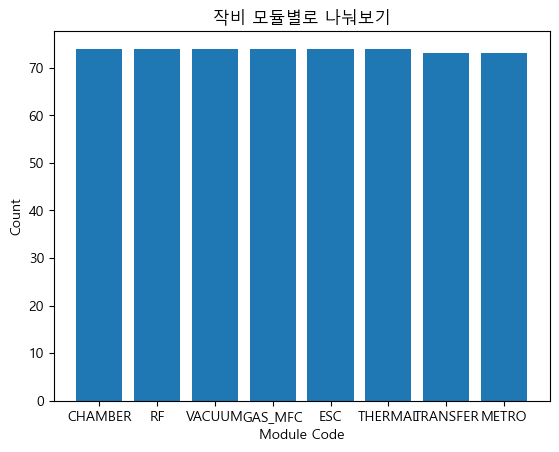

In [39]:
# TODO 5-1: 남은 신호의 메타데이터만 추출 (힌트: .isin())
meta_keep = df.columns[df.columns.isin(keep_cols)]
print(meta_keep)

# TODO 5-2: 모듈별 개수 세기 (힌트: value_counts)
by_module = meta['module_code'].value_counts()
print(by_module)

# TODO 5-3: 막대그래프. 제목과 축 이름을 꼭 넣으세요
import matplotlib.pyplot as plt
plt.bar(by_module.index, by_module.values)
plt.title('작비 모듈별로 나눠보기')
plt.xlabel('Module Code')
plt.ylabel('Count')
plt.show()

자가진단 5 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [36]:
check('meta_keep 446행', meta_keep is not None and len(meta_keep) == 446, None if meta_keep is None else len(meta_keep))
check('모듈 8종', by_module is not None and len(by_module) == 8)

[통과] meta_keep 446행
[통과] 모듈 8종


---

## 미션 6 · 불량 관련 신호 Top 10 찾기

오늘의 본론입니다.

불량 웨이퍼와 양품 웨이퍼의 신호 값을 비교해서 차이가 큰 신호를 찾습니다.
그런데 신호마다 단위가 다릅니다. 어떤 건 3000 언저리이고 어떤 건 0.1 언저리입니다.
그냥 빼서 비교하면 값이 큰 신호가 무조건 이깁니다.

그래서 표준편차로 나눠줍니다. 이렇게 하면 단위가 사라져서 신호끼리 공정하게 비교됩니다.
이 값을 효과크기라고 부릅니다.

```
효과크기 = | (불량 평균 - 양품 평균) / 전체 표준편차 |
```

표준편차가 0인 신호는 0으로 나누게 되니 `np.nan` 으로 바꿔두고 계산하세요.

SIG_060    0.626524
SIG_104    0.607336
SIG_511    0.528752
SIG_349    0.525317
SIG_432    0.481663
SIG_435    0.447025
SIG_431    0.438203
SIG_022    0.435065
SIG_436    0.434770
SIG_437    0.426171
dtype: float64
     index module_code module_kr sensor_type  unit  missing_rate  n_unique  \
0  SIG_060     GAS_MFC      가스공급        라인압력   psi        0.0045      1500   
1  SIG_104       METRO        계측        표면조도    nm        0.0013       153   
2  SIG_511    TRANSFER        이송       진공척흡착   kPa        0.0013      1498   
3  SIG_349         ESC       정전척         척전압     V        0.0153       357   
4  SIG_432       METRO        계측        표면조도    nm        0.0013      1553   
5  SIG_435      VACUUM        진공     게이트밸브개도     %        0.0013      1537   
6  SIG_431    TRANSFER        이송       진공척흡착   kPa        0.0013      1551   
7  SIG_022     THERMAL      온도제어       쿨런트온도  degC        0.0013      1295   
8  SIG_436     GAS_MFC      가스공급        라인압력   psi        0.0013      1524   
9  SI

C:\Users\user\AppData\Local\Temp\ipykernel_38680\2033208276.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[top_signal][is_fail], X[top_signal][~is_fail]], labels=['Fail', 'Pass'])


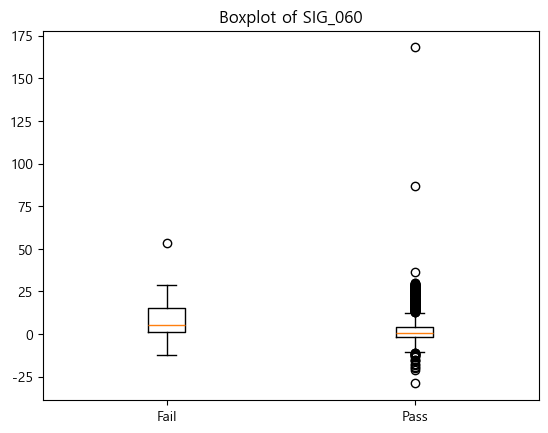

In [67]:
# TODO 6-1: 불량 마스크
is_fail = df['label'] == 1

# TODO 6-2: 그룹별 평균
mean_fail = X[is_fail].mean()
mean_pass = X[~is_fail].mean()

# TODO 6-3: 효과크기 (절댓값, 큰 순서로 정렬)
effect = ((mean_fail - mean_pass)/X.std()).sort_values(ascending=False)

# TODO 6-4: Top 10 을 meta 와 합쳐 표로 출력
top10 = effect.head(10)
meta_top10 = meta.set_index('signal_id').loc[top10.index].reset_index()
print(top10)
print(meta_top10)


# TODO 6-5: 1등 신호의 양품 vs 불량 박스플롯
# 1등 신호의 양품 vs 불량 박스플롯
top_signal = top10.index[0]
plt.boxplot([X[top_signal][is_fail], X[top_signal][~is_fail]], labels=['Fail', 'Pass'])
plt.title(f'Boxplot of {top_signal}')
plt.show()



자가진단 6 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [59]:
check('불량 104건', is_fail is not None and int(is_fail.sum()) == 104)
check('효과크기 계산', effect is not None and len(effect.dropna()) > 400)
check('1위 SIG_060', top10 is not None and top10.index[0] == 'SIG_060', None if top10 is None else top10.index[0])
check('2위 SIG_104', top10 is not None and top10.index[1] == 'SIG_104')
check('1위 효과크기 0.627', top10 is not None and abs(top10.iloc[0] - 0.6265) < 0.01)

[통과] 불량 104건
[통과] 효과크기 계산
[통과] 1위 SIG_060
[통과] 2위 SIG_104
[통과] 1위 효과크기 0.627


---

## 미션 7 · 시간에 따른 불량률 변화

장비는 시간이 지나면서 상태가 변합니다. 소모품이 닳고, 챔버가 오염되고, 정기점검을 받습니다.
예지보전의 출발점은 불량이 언제 몰렸는지 보는 것입니다.

월별로 처리량과 불량률을 집계하고 선그래프로 그리세요.
그래프를 보면서 미션 8에서 뭐라고 쓸지 생각해 두세요.

0       2008-07
1       2008-07
2       2008-07
3       2008-07
4       2008-07
         ...   
1562    2008-10
1563    2008-10
1564    2008-10
1565    2008-10
1566    2008-10
Name: month, Length: 1567, dtype: period[M]
월별 데이터가 4개월치인지 확인: True

[월별 집계 데이터프레임]
         처리량  불량수       불량률
month                      
2008-07   63   14  0.222222
2008-08  555   51  0.091892
2008-09  590   17  0.028814
2008-10  359   22  0.061281


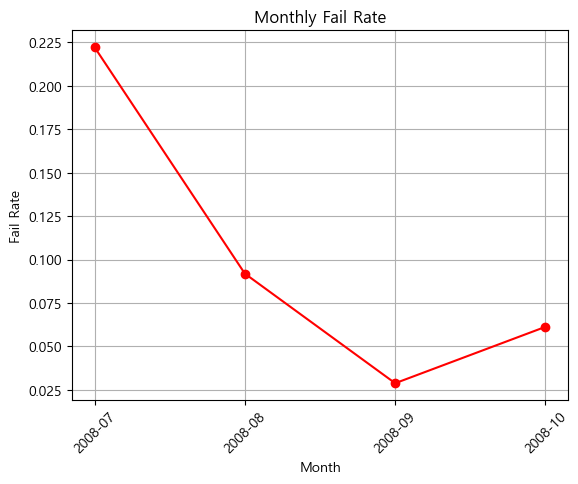

In [111]:
# TODO 7-1: 월 단위 컬럼 만들기
#   힌트: df['timestamp'].dt.to_period('M')
#   (아래에 직접 작성하세요)

df['month'] = df['timestamp'].dt.to_period('M')
print(df['month'])


# TODO 7-2: 월별 처리량 / 불량수 / 불량률
# 월별 처리량 4개월 집계 
monthly_total = df.groupby('month').size()
monthly_fail = df[is_fail].groupby('month').size()


# 데이터프레임으로 묶기
monthly = pd.DataFrame({
    '처리량': monthly_total,
    '불량수': monthly_fail
})


# 월별 불량률 컬럼 추가
monthly['불량률'] = monthly['불량수'] / monthly['처리량']

# 💡 4개월 집계가 맞는지 확인하는 코드 (True면 4개월 데이터가 정확히 있는 것)
print("월별 데이터가 4개월치인지 확인:", len(monthly) == 4)

print("\n[월별 집계 데이터프레임]")
print(monthly)




# TODO 7-3: 월별 불량률 선그래프
# Period 타입 인덱스 때문에 생기는 오류를 방지하기 위해 인덱스를 문자열로 변환
plt.plot(monthly.index.astype(str), monthly['불량률'], marker='o', color='red')

plt.title('Monthly Fail Rate')
plt.xlabel('Month')
plt.ylabel('Fail Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

자가진단 7 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [112]:
check('month 컬럼', df is not None and 'month' in df.columns and df['month'].notna().all())
check('4개월 집계', monthly is not None and len(monthly) == 4, '2008년 7~10월')
check('7월이 가장 높음', monthly is not None and monthly['불량률'].idxmax() == monthly.index[0])

[통과] month 컬럼
[통과] 4개월 집계
[통과] 7월이 가장 높음


---

## 미션 8 · 정리해서 쓰기

여기부터는 코드가 아니라 글입니다. 아래 항목을 본인 문장으로 채우세요.
숫자를 근거로 인용해야 합니다. 446개, 6.64% 같은 식으로요.

---

**1. 데이터가 어떤 것이었나**

웨이퍼 몇 장, 신호 몇 개, 불량률은 얼마였습니까.

답:

**2. 무엇을 왜 버렸나**

590개 중 144개를 뺐습니다. 어떤 기준으로 뺐고, 그 기준이 왜 타당합니까.

답:

**3. 어떤 신호가 걸렸나**

Top 10에 어느 모듈이 많이 나왔습니까. 1등 신호의 박스플롯에서 무엇이 보였습니까.

답:

**4. 시간에 따라 어떻게 변했나**

월별 불량률이 어떻게 움직였고, 원인으로 무엇을 의심할 수 있습니까.

답:

**5. 공정팀에 보내는 한 문단**

어느 모듈을 먼저 점검하라고 권하겠습니까. 근거를 넣어 한 문단으로 쓰세요.

답:

**6. 이 분석으로 말할 수 없는 것**

이 결과만으로 단정할 수 없는 이유를 최소 두 가지 쓰세요.
효과크기가 크면 그 신호가 원인입니까. 불량 104건은 충분합니까. 신호 이름은 진짜입니까.

답:

---

### 제출 전 확인

- [ ] 자가진단이 모두 `[통과]` 인가
- [ ] 그래프 세 개(막대·박스·선)에 제목과 축 이름이 있는가
- [ ] 미션 8의 여섯 항목을 본인 문장으로 채웠는가
- [ ] 커널 재시작 후 전체 실행이 오류 없이 끝나는가
- [ ] 파일명을 `W01_학번_이름.ipynb` 로 바꿨는가